# 05 - Thresholds, SHAP Explainability, and Demo Cases

Purpose:

- Load saved PCOS models.
- Compare global drivers across screening and enhanced models.
- Compute SHAP-based per-patient explanations.
- Build demo predictions from **held-out** test rows so explanations are honest.
- Emit a model card for the deck.

Run after notebooks 02 and 03.


In [1]:
from pathlib import Path
import re
import json
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "_read_extract"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
METRIC_DIR = OUTPUT_DIR / "metrics"

for folder in [RAW_DIR, OUTPUT_DIR, FIGURE_DIR, MODEL_DIR, METRIC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ZIP_PATH = PROJECT_ROOT / "OneDrive_1_5-11-2026.zip"
PCOS_XLSX = RAW_DIR / "(Main_Dataset)_PCOS_data_without_infertility.xlsx"
ENDO_CSV = RAW_DIR / "(Supplementary_Dataset)_structured_endometriosis_data.csv"

def ensure_small_datasets_extracted():
    """Extract only the tabular datasets if they are not already available."""
    if PCOS_XLSX.exists() and ENDO_CSV.exists():
        return
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"Cannot find {ZIP_PATH}")
    targets = {
        "(Main_Dataset)_PCOS_data_without_infertility.xlsx": PCOS_XLSX,
        "(Supplementary_Dataset)_structured_endometriosis_data.csv": ENDO_CSV,
    }
    with zipfile.ZipFile(ZIP_PATH) as zf:
        for member, destination in targets.items():
            if not destination.exists():
                with zf.open(member) as src, open(destination, "wb") as dst:
                    dst.write(src.read())

ensure_small_datasets_extracted()

def clean_column_name(name):
    name = str(name).strip().lower()
    name = name.replace("β", "beta")
    name = name.replace("marraige", "marriage")
    name = name.replace("bp _", "bp ")
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name

# Columns we never want to keep, even though they parse as numeric.
# - sl_no / patient_file_no: identifiers, no clinical signal.
# - blood_group: stored as ordinal codes (11-18) which has no meaningful order.
# - marriage_status_yrs: clinically sensitive and a poor proxy for anything
#   diagnostic; the plan flags it as unsuitable for screening.
DROP_COLUMNS = ["sl_no", "patient_file_no", "blood_group", "marriage_status_yrs"]

def load_pcos_raw():
    df = pd.read_excel(PCOS_XLSX, sheet_name="Full_new", engine="openpyxl")
    df = df.dropna(how="all").copy()
    df.columns = [clean_column_name(c) for c in df.columns]
    df = df.loc[:, ~df.columns.duplicated()].copy()
    return df

def clean_pcos_dataframe(df):
    df = df.copy()

    # Track silently-coerced non-numeric cells so the audit can flag them.
    coercion_report = {}
    for col in df.columns:
        before_non_null = df[col].notna().sum()
        coerced = pd.to_numeric(df[col], errors="coerce")
        new_nan = coerced.isna().sum() - df[col].isna().sum()
        if new_nan > 0:
            offending = df.loc[df[col].notna() & coerced.isna(), col].astype(str).unique().tolist()
            coercion_report[col] = {"coerced_to_nan": int(new_nan), "examples": offending[:5]}
        df[col] = coerced

    drop_now = [c for c in DROP_COLUMNS if c in df.columns]
    df = df.drop(columns=drop_now)

    if "pcos_y_n" not in df.columns:
        raise ValueError("Expected target column 'pcos_y_n' after cleaning column names.")

    df = df[df["pcos_y_n"].isin([0, 1])].copy()
    df["pcos_y_n"] = df["pcos_y_n"].astype(int)

    # Kaggle-style encoding uses 2 for regular and 4/5 for irregular cycles.
    if "cycle_r_i" in df.columns:
        df["cycle_irregular_flag"] = np.where(
            df["cycle_r_i"].isna(),
            np.nan,
            np.where(df["cycle_r_i"] >= 4, 1, 0),
        )

    # Conservative caps for visibly impossible or model-dominating outliers.
    caps = {
        "fsh_miu_ml": (0, 100),
        "lh_miu_ml": (0, 200),
        "fsh_lh": (0, 50),
        "vit_d3_ng_ml": (0, 150),
        "prg_ng_ml": (0, 50),
    }
    for col, (low, high) in caps.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=low, upper=high)

    df.attrs["coercion_report"] = coercion_report
    df.attrs["dropped_columns"] = drop_now
    return df

pcos_raw = load_pcos_raw()
pcos = clean_pcos_dataframe(pcos_raw)
print("PCOS shape:", pcos.shape)
print("Dropped columns:", pcos.attrs["dropped_columns"])
if pcos.attrs["coercion_report"]:
    print("Non-numeric values coerced to NaN:")
    for col, info in pcos.attrs["coercion_report"].items():
        print(f"  {col}: {info['coerced_to_nan']} cell(s); examples={info['examples']}")
print(pcos["pcos_y_n"].value_counts().sort_index())



TARGET = "pcos_y_n"

# fast_food_y_n and reg_exercise_y_n are deliberately excluded.
# The plan flags lifestyle proxies as bias-prone and likely to stigmatise patients.
SCREENING_FEATURES = [
    "age_yrs",
    "bmi",
    "cycle_r_i",
    "cycle_irregular_flag",
    "cycle_length_days",
    "weight_gain_y_n",
    "hair_growth_y_n",
    "skin_darkening_y_n",
    "hair_loss_y_n",
    "pimples_y_n",
    "rbs_mg_dl",
    "bp_systolic_mmhg",
    "bp_diastolic_mmhg",
]

ENHANCED_EXTRA_FEATURES = [
    "hb_g_dl",
    "fsh_miu_ml",
    "lh_miu_ml",
    "fsh_lh",
    "tsh_miu_l",
    "amh_ng_ml",
    "prl_ng_ml",
    "vit_d3_ng_ml",
    "prg_ng_ml",
    "follicle_no_l",
    "follicle_no_r",
    "avg_f_size_l_mm",
    "avg_f_size_r_mm",
    "endometrium_mm",
]

def available(features, df):
    return [feature for feature in features if feature in df.columns]

screening_features = available(SCREENING_FEATURES, pcos)
enhanced_features = available(SCREENING_FEATURES + ENHANCED_EXTRA_FEATURES, pcos)

print("Screening features:", screening_features)
print("Enhanced features:", enhanced_features)



from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib



def make_models():
    return {
        "dummy_most_frequent": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "logistic_regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        "random_forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=4,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
        "gradient_boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]),
    }

SCORING = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
}

def cross_validate_models(X, y, models, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=SCORING, n_jobs=-1, error_score="raise")
        row = {"model": name}
        for metric in SCORING:
            row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
            row[f"{metric}_std"] = scores[f"test_{metric}"].std()
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["roc_auc_mean", "recall_mean"], ascending=False)

def cv_oof_probabilities(model, X, y, n_splits=5):
    """Out-of-fold positive-class probabilities for threshold tuning without leakage."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_predict(model, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

def evaluate_holdout(model, X_test, y_test, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_test, proba),
        "recall": recall_score(y_test, pred),
        "specificity": recall_score(y_test, pred, pos_label=0),
        "precision": precision_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "confusion_matrix": confusion_matrix(y_test, pred).tolist(),
    }

def choose_high_recall_threshold(y_true, y_proba, min_recall=0.90):
    thresholds = np.round(np.linspace(0.05, 0.95, 181), 3)
    rows = []
    for threshold in thresholds:
        pred = (y_proba >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "recall": recall_score(y_true, pred),
            "specificity": recall_score(y_true, pred, pos_label=0),
            "precision": precision_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        })
    table = pd.DataFrame(rows)
    candidates = table[table["recall"] >= min_recall]
    if len(candidates):
        chosen = candidates.sort_values(["specificity", "precision", "f1"], ascending=False).iloc[0]
    else:
        chosen = table.sort_values(["f1", "balanced_accuracy"], ascending=False).iloc[0]
    return chosen, table

def make_risk_tier(threshold):
    """Risk tiers anchored to the model's action threshold so labels never contradict predictions."""
    high_cutoff = min(0.90, threshold + 0.20)
    def risk_tier(probability):
        if probability < threshold:
            return "Low"
        if probability < high_cutoff:
            return "Moderate"
        return "High"
    return risk_tier

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


PCOS shape: (541, 41)
Dropped columns: ['sl_no', 'patient_file_no', 'blood_group', 'marriage_status_yrs']
Non-numeric values coerced to NaN:
  ii_beta_hcg_miu_ml: 1 cell(s); examples=['1.99.']
  amh_ng_ml: 1 cell(s); examples=['a']
pcos_y_n
0    364
1    177
Name: count, dtype: int64
Screening features: ['age_yrs', 'bmi', 'cycle_r_i', 'cycle_irregular_flag', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'rbs_mg_dl', 'bp_systolic_mmhg', 'bp_diastolic_mmhg']
Enhanced features: ['age_yrs', 'bmi', 'cycle_r_i', 'cycle_irregular_flag', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'rbs_mg_dl', 'bp_systolic_mmhg', 'bp_diastolic_mmhg', 'hb_g_dl', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh', 'tsh_miu_l', 'amh_ng_ml', 'prl_ng_ml', 'vit_d3_ng_ml', 'prg_ng_ml', 'follicle_no_l', 'follicle_no_r', 'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm']


## Load Saved Artifacts


In [2]:
screening_path = MODEL_DIR / "pcos_screening_model.joblib"
enhanced_path = MODEL_DIR / "pcos_enhanced_model.joblib"

if not screening_path.exists() or not enhanced_path.exists():
    raise FileNotFoundError("Run notebooks 02 and 03 before this notebook.")

screening_artifact = joblib.load(screening_path)
enhanced_artifact = joblib.load(enhanced_path)

print("Screening model:", screening_artifact["model_name"], "threshold:", screening_artifact["threshold"])
print("Enhanced model:", enhanced_artifact["model_name"], "threshold:", enhanced_artifact["threshold"])


Screening model: random_forest threshold: 0.285
Enhanced model: random_forest threshold: 0.38


## Global Feature Drivers


In [3]:
def extract_feature_importance(artifact):
    model = artifact["model"]
    features = artifact["features"]
    estimator = model.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
        kind = "tree_importance"
    elif hasattr(estimator, "coef_"):
        values = estimator.coef_[0]
        kind = "standardized_log_odds_coefficient"
    else:
        return pd.DataFrame({"feature": features, "importance": np.nan, "kind": "not_available"})

    table = pd.DataFrame({
        "feature": features,
        "importance": values,
        "abs_importance": np.abs(values),
        "kind": kind,
    }).sort_values("abs_importance", ascending=False)
    return table

screening_importance = extract_feature_importance(screening_artifact)
enhanced_importance = extract_feature_importance(enhanced_artifact)

screening_importance.to_csv(METRIC_DIR / "screening_feature_importance.csv", index=False)
enhanced_importance.to_csv(METRIC_DIR / "enhanced_feature_importance.csv", index=False)

display(screening_importance.head(15))
display(enhanced_importance.head(20))


,feature,importance,abs_importance,kind
7,skin_darkening_y_n,0.180294,0.180294,tree_importance
6,hair_growth_y_n,0.151882,0.151882,tree_importance
5,weight_gain_y_n,0.131406,0.131406,tree_importance
1,bmi,0.090393,0.090393,tree_importance
4,cycle_length_days,0.085580,0.085580,tree_importance
0,age_yrs,0.084028,0.084028,tree_importance
10,rbs_mg_dl,0.063340,0.063340,tree_importance
9,pimples_y_n,0.054914,0.054914,tree_importance
3,cycle_irregular_flag,0.052415,0.052415,tree_importance
2,cycle_r_i,0.049624,0.049624,tree_importance


,feature,importance,abs_importance,kind
23,follicle_no_r,0.244982,0.244982,tree_importance
22,follicle_no_l,0.174033,0.174033,tree_importance
7,skin_darkening_y_n,0.069308,0.069308,tree_importance
5,weight_gain_y_n,0.064993,0.064993,tree_importance
6,hair_growth_y_n,0.064934,0.064934,tree_importance
18,amh_ng_ml,0.045247,0.045247,tree_importance
4,cycle_length_days,0.027104,0.027104,tree_importance
1,bmi,0.025447,0.025447,tree_importance
2,cycle_r_i,0.022643,0.022643,tree_importance
3,cycle_irregular_flag,0.021724,0.021724,tree_importance


## Plot Feature Drivers


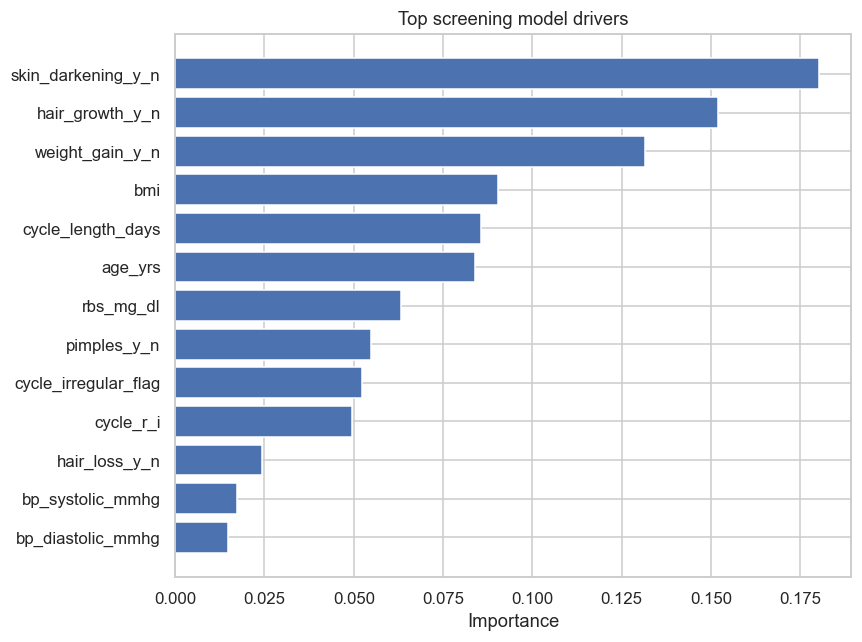

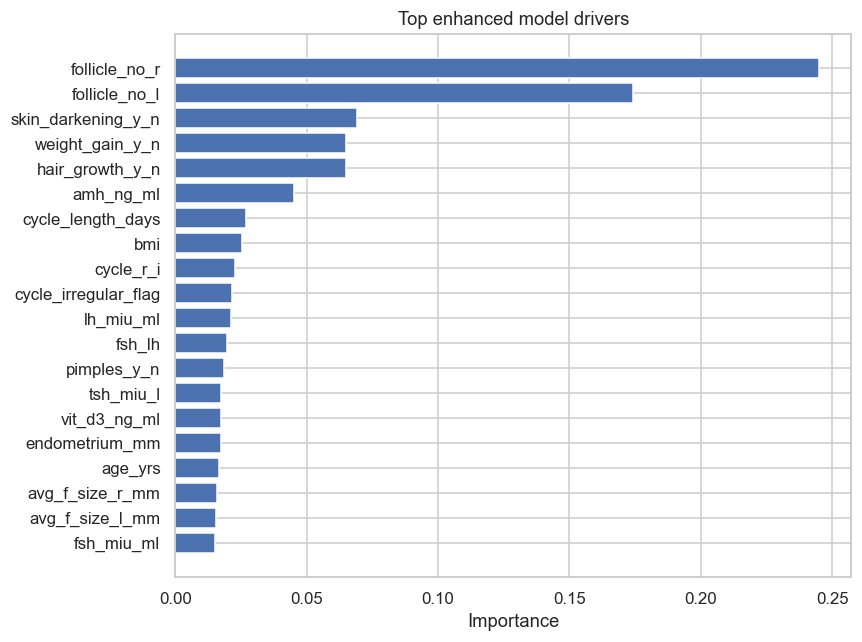

In [4]:
def plot_importance(table, title, path, n=15):
    plot_data = table.head(n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(plot_data["feature"], plot_data["importance"])
    ax.set_title(title)
    ax.set_xlabel("Importance")
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()

plot_importance(
    screening_importance,
    "Top screening model drivers",
    FIGURE_DIR / "screening_feature_importance.png",
    n=15,
)

plot_importance(
    enhanced_importance,
    "Top enhanced model drivers",
    FIGURE_DIR / "enhanced_feature_importance.png",
    n=20,
)


## Hold-out Demo Cases

Reproduce the test split with the same seed so demo cases come from rows the models never saw during training.


In [5]:
def holdout_indices(features):
    X = pcos[features].copy()
    y = pcos[TARGET].copy()
    _, X_test, _, y_test = train_test_split(
        X, y,
        test_size=0.25,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    return X_test.index, y_test

enh_test_idx, enh_y_test = holdout_indices(enhanced_artifact["features"])

# enh_y_test is indexed by the test split's row labels, matching enh_test_idx.
positive_test_idx = enh_test_idx[enh_y_test.values == 1][0]
negative_test_idx = enh_test_idx[enh_y_test.values == 0][0]

positive_case = pcos.loc[positive_test_idx].to_dict()
negative_case = pcos.loc[negative_test_idx].to_dict()

print(f"Positive holdout row index: {positive_test_idx}")
print(f"Negative holdout row index: {negative_test_idx}")


Positive holdout row index: 395
Negative holdout row index: 383


## Patient-Level Predictions with Threshold-Aware Risk Tiers


In [6]:
def predict_with_artifact(row, artifact):
    features = artifact["features"]
    model = artifact["model"]
    threshold = artifact["threshold"]
    tier_fn = make_risk_tier(threshold)
    X_one = pd.DataFrame([row])[features]
    probability = float(model.predict_proba(X_one)[:, 1][0])
    return {
        "probability": probability,
        "threshold": float(threshold),
        "prediction": int(probability >= threshold),
        "risk_tier": tier_fn(probability),
    }

demo_results = {
    "known_pcos_case_screening": predict_with_artifact(positive_case, screening_artifact),
    "known_pcos_case_enhanced": predict_with_artifact(positive_case, enhanced_artifact),
    "known_non_pcos_case_screening": predict_with_artifact(negative_case, screening_artifact),
    "known_non_pcos_case_enhanced": predict_with_artifact(negative_case, enhanced_artifact),
}

save_json(demo_results, METRIC_DIR / "demo_case_predictions.json")
demo_results


{'known_pcos_case_screening': {'probability': 0.8860810540060967,
  'threshold': 0.285,
  'prediction': 1,
  'risk_tier': 'High'},
 'known_pcos_case_enhanced': {'probability': 0.9067223837392016,
  'threshold': 0.38,
  'prediction': 1,
  'risk_tier': 'High'},
 'known_non_pcos_case_screening': {'probability': 0.20790098425682638,
  'threshold': 0.285,
  'prediction': 0,
  'risk_tier': 'Low'},
 'known_non_pcos_case_enhanced': {'probability': 0.21383710032615938,
  'threshold': 0.38,
  'prediction': 0,
  'risk_tier': 'Low'}}

## SHAP-Based Per-Patient Explanations

SHAP attributes each feature's contribution to a single patient's predicted log-odds. For tree models we use `TreeExplainer`; for logistic regression we use `LinearExplainer` on the scaled feature space.


In [7]:
import shap

def transform_through_preprocessing(model, X_row):
    """Apply every pipeline step except the final estimator."""
    X = X_row.copy()
    for _, transformer in model.steps[:-1]:
        X = transformer.transform(X)
    return X

def shap_for_artifact(artifact, row, background=None, top_n=8):
    features = artifact["features"]
    model = artifact["model"]
    estimator = model.named_steps["model"]

    X_row = pd.DataFrame([row])[features]
    X_transformed = transform_through_preprocessing(model, X_row)

    if hasattr(estimator, "feature_importances_"):
        explainer = shap.TreeExplainer(estimator)
        sv = explainer.shap_values(X_transformed)
        if isinstance(sv, list):
            values = sv[1][0] if len(sv) > 1 else sv[0][0]
        elif np.ndim(sv) == 3:
            values = sv[0, :, 1]
        else:
            values = sv[0]
    elif hasattr(estimator, "coef_"):
        if background is None:
            background = X_transformed
        explainer = shap.LinearExplainer(estimator, background)
        values = np.array(explainer.shap_values(X_transformed))[0]
    else:
        return None

    table = pd.DataFrame({
        "feature": features,
        "patient_value": X_row.iloc[0].values,
        "shap_log_odds_contribution": values,
    })
    table["abs"] = table["shap_log_odds_contribution"].abs()
    return table.sort_values("abs", ascending=False).drop(columns="abs").head(top_n).reset_index(drop=True)

# Build a small background sample on the *training* slice for linear SHAP.
def training_background(artifact, size=100):
    features = artifact["features"]
    X = pcos[features].copy()
    y = pcos[TARGET].copy()
    X_train, _, _, _ = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE,
    )
    sample = X_train.sample(min(size, len(X_train)), random_state=RANDOM_STATE)
    return transform_through_preprocessing(artifact["model"], sample)

screening_background = training_background(screening_artifact)
enhanced_background = training_background(enhanced_artifact)

print("SHAP - positive holdout case, screening model:")
screening_shap = shap_for_artifact(screening_artifact, positive_case, background=screening_background)
display(screening_shap)

print("SHAP - positive holdout case, enhanced model:")
enhanced_shap = shap_for_artifact(enhanced_artifact, positive_case, background=enhanced_background)
display(enhanced_shap)

screening_shap.to_csv(METRIC_DIR / "demo_positive_screening_shap.csv", index=False)
enhanced_shap.to_csv(METRIC_DIR / "demo_positive_enhanced_shap.csv", index=False)


SHAP - positive holdout case, screening model:


,feature,patient_value,shap_log_odds_contribution
0,skin_darkening_y_n,1.000000,0.137388
1,weight_gain_y_n,1.000000,0.096521
2,cycle_length_days,3.000000,0.058388
3,hair_growth_y_n,0.000000,-0.053721
4,cycle_r_i,4.000000,0.047760
5,cycle_irregular_flag,1.000000,0.046067
6,pimples_y_n,1.000000,0.041808
7,bmi,29.270994,0.011630


SHAP - positive holdout case, enhanced model:


,feature,patient_value,shap_log_odds_contribution
0,follicle_no_r,9.0,0.091530
1,follicle_no_l,10.0,0.090492
2,skin_darkening_y_n,1.0,0.068744
3,weight_gain_y_n,1.0,0.066182
4,hair_growth_y_n,0.0,-0.030693
5,cycle_length_days,3.0,0.029017
6,cycle_irregular_flag,1.0,0.028502
7,cycle_r_i,4.0,0.025264


## SHAP Waterfall Plots


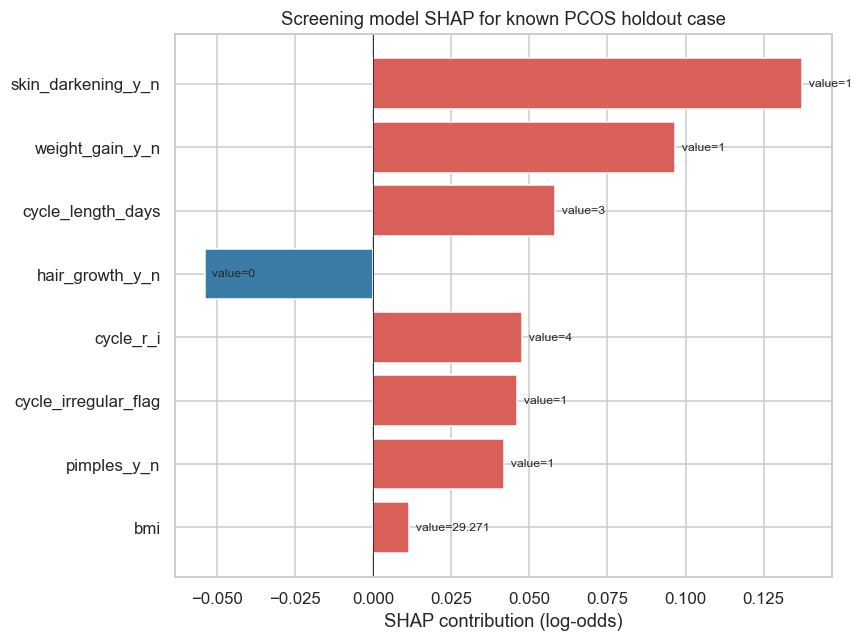

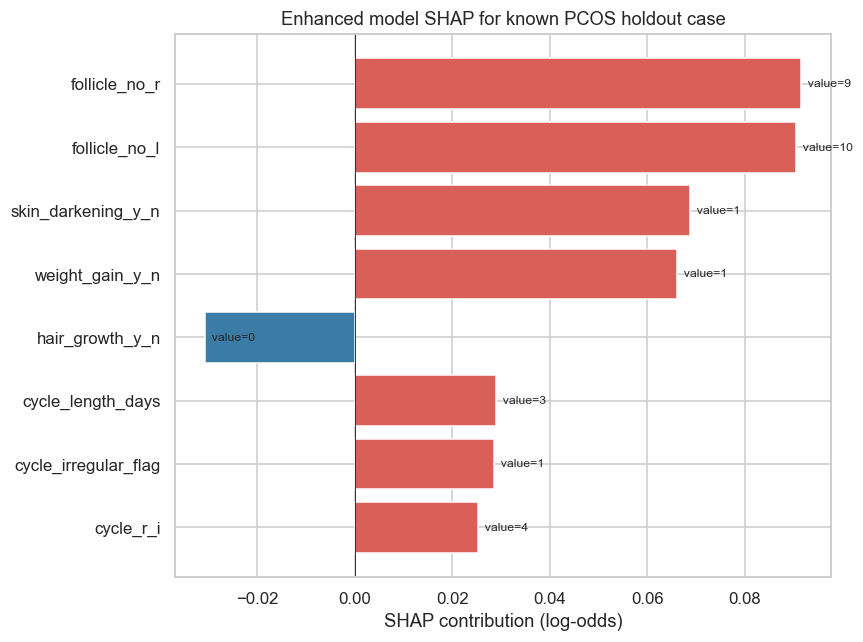

In [8]:
def plot_shap_bars(table, title, path):
    plot_data = table.iloc[::-1]
    colors = ["#d95f59" if v > 0 else "#3a7ca5" for v in plot_data["shap_log_odds_contribution"]]
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(plot_data) + 2))
    ax.barh(plot_data["feature"], plot_data["shap_log_odds_contribution"], color=colors)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel("SHAP contribution (log-odds)")
    for i, (val, pv) in enumerate(zip(plot_data["shap_log_odds_contribution"], plot_data["patient_value"])):
        ax.text(val, i, f"  value={pv:g}", va="center", fontsize=8)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()

plot_shap_bars(
    screening_shap,
    "Screening model SHAP for known PCOS holdout case",
    FIGURE_DIR / "screening_shap_positive_case.png",
)
plot_shap_bars(
    enhanced_shap,
    "Enhanced model SHAP for known PCOS holdout case",
    FIGURE_DIR / "enhanced_shap_positive_case.png",
)


## Model Card


In [9]:
model_card = f"""
# PCOS Pathfinder Model Card

## Intended use

Decision support for PCOS risk screening and diagnostic triage. **Not** a standalone diagnostic device.

## Data

- Required PCOS clinical dataset (10 hospitals, Kerala, India).
- Cleaned rows: {len(pcos)}
- PCOS-positive: {int(pcos[TARGET].sum())} | PCOS-negative: {int((pcos[TARGET] == 0).sum())}
- Columns dropped during cleaning: {pcos.attrs.get("dropped_columns", [])}

## Models

### Screening model

- Algorithm: {screening_artifact["model_name"]}
- Features: {len(screening_artifact["features"])} (no lifestyle proxies)
- Threshold: {screening_artifact["threshold"]:.3f} (chosen on training CV at recall>=0.90)
- Holdout ROC-AUC: {screening_artifact["metrics"].get("roc_auc"):.3f}
- Holdout recall / specificity: {screening_artifact["metrics"].get("recall"):.3f} / {screening_artifact["metrics"].get("specificity"):.3f}

### Enhanced model

- Algorithm: {enhanced_artifact["model_name"]}
- Features: {len(enhanced_artifact["features"])}
- Threshold: {enhanced_artifact["threshold"]:.3f} (chosen on training CV at recall>=0.90)
- Holdout ROC-AUC: {enhanced_artifact["metrics"].get("roc_auc"):.3f}
- Holdout recall / specificity: {enhanced_artifact["metrics"].get("recall"):.3f} / {enhanced_artifact["metrics"].get("specificity"):.3f}

## Explainability

- Global: tree feature importances or scaled logistic-regression coefficients.
- Local: SHAP attributions for each prediction.

## Limitations

- Single-source geography (Kerala, India); generalisation requires external validation.
- Small dataset ({len(pcos)} rows).
- Endometriosis overlap module uses synthetic data and only prompts further workup.
- Demographic equity variables (race, income, access to care) are not available.
- Outputs must be combined with clinical judgement.
"""

model_card_path = METRIC_DIR / "pcos_model_card.md"
model_card_path.write_text(model_card, encoding="utf-8")
print("Saved:", model_card_path)
print(model_card)


Saved: C:\Users\kex03\Downloads\biohackathon\outputs\metrics\pcos_model_card.md

# PCOS Pathfinder Model Card

## Intended use

Decision support for PCOS risk screening and diagnostic triage. **Not** a standalone diagnostic device.

## Data

- Required PCOS clinical dataset (10 hospitals, Kerala, India).
- Cleaned rows: 541
- PCOS-positive: 177 | PCOS-negative: 364
- Columns dropped during cleaning: ['sl_no', 'patient_file_no', 'blood_group', 'marriage_status_yrs']

## Models

### Screening model

- Algorithm: random_forest
- Features: 13 (no lifestyle proxies)
- Threshold: 0.285 (chosen on training CV at recall>=0.90)
- Holdout ROC-AUC: 0.896
- Holdout recall / specificity: 0.886 / 0.685

### Enhanced model

- Algorithm: random_forest
- Features: 27
- Threshold: 0.380 (chosen on training CV at recall>=0.90)
- Holdout ROC-AUC: 0.953
- Holdout recall / specificity: 0.886 / 0.902

## Explainability

- Global: tree feature importances or scaled logistic-regression coefficients.
- Local: S